# Data Preparation

## Recap of `Fundamentals of Machine Learning`

## Regression vs. Classification
<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/regression_vs_classif.png' width=400 style='margin:auto'> 


### The Sklearn modelling workflow

```python
from sklearn.some_module import SomeModel

model = SomeModel()
model.fit(X_train,y_train)
model.score(X_test,y_test)
model.predict(X_new)
```

### The Holdout Method

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/train_test_split.png' width=400 style='margin:auto'> 

### The Holdout Method - Dataframe view

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/holdout.png' width=400 style='margin:auto'> 

### The Holdout Method in `Scikit-Learn`

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=88)
```

## K-Fold Cross validation

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/K_fold_3.png' width=500 style='margin:auto'> 


### Cross validation - Dataframe view

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/k_fold_df_view_2.png' width=500 style='margin:auto'> 

### Cross validation in `Scikit-Learn`

```python
from sklearn.model_selection import cross_validate

cross_validate(model, X, y, cv = 5) # returns test_score, fit_time and score_time
```

### Bias/Variance tradeoff

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/over_under_bias_variance.png' width=900 style='margin:auto'> 

### Learning Curves

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/optimum_learning_curve.png' width=600 align="center"> 

## Plan of the lecture (1/2)

***General prerequisites***

(1) 👥 Duplicates

(2) 🔮 Missing data

(3) 🐳 Outliers

***Numerical columns***

(4) 🔢 Scaling

## Plan of the lecture (2/2)

***Balanced datasets***  

(5) ⚖️ Balancing

***Categorical columns***

(6) 🔠 Encoding


(7) 🟨 Discretizing

***Generating new features***

(8) 🟨 Feature creation

***Using the most relevant features***   

(9) 🤖 Feature selection, Modelling and Feature Permutation


<img align="center" src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/roadmap_preprocessing.png'  width=800>

## 🛠 Why preprocessing?

- Raw data is dirty and noisy
- Machine learning algorithms have certain constraints regarding input data
- Transformations can improve the model performance

<img align="center" src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/preprocessing_cartoon.png'  width=300 height = 200>

<center>🔗 <a href="https://xkcd.com/1838/">Source</a></center>


<img align="center" src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/datascience.jpg'  width=700>

<center>🔗 <a href="hhttps://visit.figure-eight.com/rs/416-ZBE-142/images/CrowdFlower_DataScienceReport_2016.pdf"> Source</a></center>


<a href='https://github.com/lewagon/data-images/raw/master/ML/preparation_steps.pdf' target="blank"><img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/preparation_steps.png' width=10000></a>

🏠 Let's consider the `Houses dataset` we used in the previous lecture `01 - Fundamentals of ML`

👉 Now, we are going to include some new features in our modeling: `Alley`,`Street`, `WallMat`, `Pesos`, and `MoSold`.

* 💾 Download the dataset [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset.csv)

* ℹ️ Have a look at the full dataset description [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset_description.txt).

In [1]:
import pandas as pd

data = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset.csv")

data = data[['GrLivArea','BedroomAbvGr','KitchenAbvGr', 'OverallCond',
             'Pesos','Alley','Street','WallMat','SalePrice']]

In [2]:
data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Alley,Street,WallMat,SalePrice
0,1710,3,1,5,4170000.0,NaN,Pave,Concrete,208500
1,1262,3,1,8,3630000.0,NaN,Pave,Wood,181500
2,1786,3,1,5,4470000.0,NaN,Pave,Wood,223500
3,1717,3,1,5,2800000.0,NaN,Pave,Concrete,140000
4,2198,4,1,5,5000000.0,NaN,Pave,Concrete,250000


# (1) 👥 Duplicates

❓ Duplicated observations can discredit the performance evaluation of a model. Why ❓

In [3]:
data[["GrLivArea","SalePrice"]].head(10)

,GrLivArea,SalePrice
0,1710,208500
1,1262,181500
2,1786,223500
3,1717,140000
4,2198,250000
5,1362,143000
6,1694,307000
7,2090,200000
8,1774,129900
9,1077,118000


## ⚠️ Data Leakage


* In order to evaluate a model's ability to generalize, <font color="black"><b><u>the data in the test set should remain unseen by the algorithm during the training phase</u></b></font>.

    * If there are <font color=red><b><i>duplicated rows</i></b></font> present in ***both*** the <font color=blue><b><i>training set</i></b></font> and the <font color="#fd7e14"><b><i>test</i></b></font> set, this can cause <font color=red><b><i>unreliable scores</i></b></font>.

<img align="center" src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/dataleakage.png'  width=400>

### 💻 `drop_duplicates`

In [4]:
len(data) # Check number of rows before removing duplicates

1760

In [5]:
data.duplicated() # Check whether a row is a duplicated version of a previous row

0       False
1       False
2       False
3       False
4       False
        ...  
1755     True
1756     True
1757     True
1758     True
1759     True
Length: 1760, dtype: bool

In [6]:
data.duplicated().sum() # Compute the number of duplicated rows

303

In [7]:
data = data.drop_duplicates() # Remove duplicates
len(data)# Check new number of rows

1457

# (2) 🔮 Missing Data 



<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/missing_data_2.png' width=300 style='margin:auto'> 

## Common reasons for missing data

- 🧑🏻‍💻 Programming error
- 😕 Failure of measurement (e.g. a patient in a clinical study misses a scheduled visit)
- 🎲 Random events (e.g. meteorological data collection device runs out of power)
- ❌ Incorrect text entries
- etc...


## Common representations for missing data
- `NaN` (_not a number_)
- `999` (_or any suspiciously large negative number..._)
- `?`
- $\pm \infty$ (infinite values)
- `""` (_Empty string_)

### 💻 Detecting missing data

In [8]:
# Counting the number of NaN for each column
data.isnull().sum().sort_values(ascending=False)

WallMat         1452
Alley           1367
Pesos             10
GrLivArea          0
BedroomAbvGr       0
KitchenAbvGr       0
OverallCond        0
Street             0
SalePrice          0
dtype: int64

In [9]:
# Counting the percentage of NaN for each column
data.isnull().sum().sort_values(ascending=False)/len(data) #NaN percentage for each column

WallMat         0.996568
Alley           0.938229
Pesos           0.006863
GrLivArea       0.000000
BedroomAbvGr    0.000000
KitchenAbvGr    0.000000
OverallCond     0.000000
Street          0.000000
SalePrice       0.000000
dtype: float64

## Handling missing data
How you handle missing values will differ from field to field and dataset to dataset.
- What might have caused the missing values?
- Do the missing values represent a particular story or event?
- Can I replace them by another value?
- Can I afford to lose any data?

🚨Some of these questions require domain knowledge. Ensure you are aware of what each column truly represents before starting any machine learning task!


👉 You can download the description of the dataset that we will be playing with [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset_description.txt).

### `WallMat`

In [10]:
# Percentage of missing values in WallMat
(data.WallMat.isnull().sum()/len(data))

0.9965682910089224

In [11]:
# 99% is way too high, let's drop this feature
data.drop(columns='WallMat', inplace=True) # Drop WallMat column
data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Alley,Street,SalePrice
0,1710,3,1,5,4170000.0,NaN,Pave,208500
1,1262,3,1,8,3630000.0,NaN,Pave,181500
2,1786,3,1,5,4470000.0,NaN,Pave,223500
3,1717,3,1,5,2800000.0,NaN,Pave,140000
4,2198,4,1,5,5000000.0,NaN,Pave,250000


### `Alley`


In [12]:
#Percentage of missing values in Alley
(data.Alley.isnull().sum()/len(data))

0.938229238160604

🚨Missing data does not necessarily mean a lack of information!

👉 Here, you have to be careful. A _NaN_ simply means that the house doesn't have an Alley.

In [13]:
import numpy as np

data.Alley.replace(np.nan, "NoAlley", inplace=True) #Replace NaN by "NoAlley"
data.Alley.value_counts()#Check count of each category


NoAlley    1367
Grvl         50
Pave         40
Name: Alley, dtype: int64

### `Pesos`

In [14]:
# Percentage of missing values in Pesos
(data.Pesos.isnull().sum()/len(data))

0.0068634179821551134

In [15]:
# Option 1: Drop rows where Pesos value is missing
data.dropna(subset=['Pesos'])

# Option 2: Replace missing Pesos values with mean
data.Pesos.replace(np.nan, data.Pesos.mean())

0       4170000.0
1       3630000.0
2       4470000.0
3       2800000.0
4       5000000.0
          ...    
1455    3500000.0
1456    4200000.0
1457    5330000.0
1458    2842500.0
1459    2950000.0
Name: Pesos, Length: 1457, dtype: float64

### 💡Suggestions:

- <u>More than 30% of missing values</u> $\rightarrow$ 🚮 Potentially drop the feature or the row
- <u>Less than 30% of missing values</u> $\rightarrow$ 💡 Consider an _imputer_ with a strategy that makes sense (cf. next slides)


🚨 Keep in mind that imputing a missing value is an approximation. This can generate potential **noise** and/or **bias** for your models.

### 🖥 Sklearn's `SimpleImputer`

With this tool called _SimpleImputer_, you can replace missing values with a strategy of your choice ( e.g. median, mean, mode, most frequent...) 

📚[**sklearn.impute.SimpleImputer**](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [16]:
from sklearn.impute import SimpleImputer

# Instantiate a SimpleImputer object with your strategy of choice
imputer = SimpleImputer(strategy="mean")

# Call the "fit" method on the object
imputer.fit(data[['Pesos']])

# Call the "transform" method on the object
data['Pesos'] = imputer.transform(data[['Pesos']])

# The mean is stored in the transformer's memory
imputer.statistics_

array([3608796.22667588])

***How did the `SimpleImputer` work?***

```python
imputer.fit()
```

1. `imputer` computes the strategy for the feature(s) it is being fitted on
2.  stores the "strategic" value as an attribute

```python
imputer.transform()
``` 
3. identifies missing values 
4. replaces missing values with the strategic value calculated in the `fit` step



👨🏻‍🏫 In Scikit Learn, there are a couple of tools designed to help you prepare a dataset before feeding a Machine Learning model with the preprocessed data. They are called  **scikit-learn transformers**
- **`.fit()`**: learns and stores constants as attributes of the transformer
- **`.transform()`**: uses these attributes to transform features of your choice from the original dataset


# (3) 🐳 Outliers

<img align = 'center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/outliers2.png'  width=300>

> ***Outliers are data points which deviate from the rest of the data.***

## Common reasons for outliers

- ⌨️ Data entry errors 
- 📐 Measurement errors 
- 🧑🏻‍🔬 Data manipulation and preprocessing errors
- 🆕 Novelties (not errors)

## Outliers affect:

- 🕵🏻‍♀️ Dataset distributions and patterns
- 🕵🏻‍♀️ Central tendency metrics such as the _mean_ of a feature 
- 🕵🏻‍♀️ Dispersion metrics such as _standard deviation_
- 🤖 Performance of a Machine Learning model

## Detecting Outliers - Boxplot

We can use ***boxplots*** visualize outliers within a dataset.

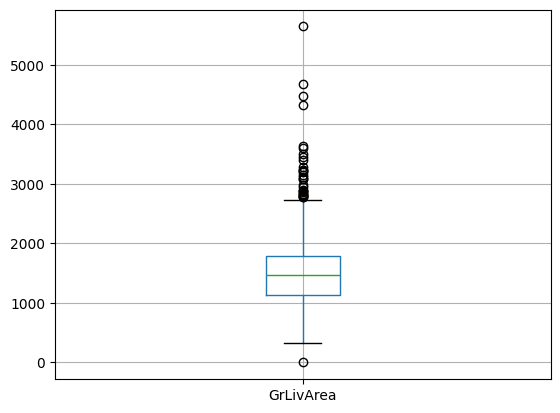

In [17]:
data[['GrLivArea']].boxplot();

* 📚 [pandas.DataFrame.boxplot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html)
* 📚 [matplotlib.pyplot.boxplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)
* 📚 [seaborn.boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

Are all the outliers "real outliers"❓ 

In [18]:
data['GrLivArea'].min()

-1

## Handling Outliers

- Is the outlier evidently false?
- Could it be a novelty?
- Could it be used as a feature?

🚨Outliers can be an opinion. We must fully comprehend what an outlier is before removing it from the dataset.

### Dropping Outliers

If data is evidently false: a house cannot have a living area of -1 $ft^2$.

In [19]:
data['GrLivArea']==-1

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: GrLivArea, Length: 1457, dtype: bool

In [20]:
# Saving the indexes corresponding to rows
# without the absurd -1 value
# and without the mansion
boolean_mask = (data['GrLivArea']>0) & (data['GrLivArea']<5000)

# Applying the boolean filteraing
data = data[boolean_mask].reset_index(drop=True)

# Visualize boxplot again
data[['GrLivArea']].boxplot();

# (4) 🔢 Feature Scaling

> 🪜 ***Feature scaling is the process of transforming <u>numerical features</u> into a $\pm$ common smaller range***

## Why scaling?

- ❗️ Features with large magnitudes can incorrectly outweigh features of small magnitudes
- ⚡️ Scaling to smaller magnitudes improves computational efficiency
- 🕵🏻‍♂️ Increases interpretability about the impact of each feature in a Machine Learning model

👇 Look at our dataset, which of these features are 🔢 numerical features? 

In [21]:
data.head(3)

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Alley,Street,SalePrice
0,1710,3,1,5,4170000.0,NoAlley,Pave,208500
1,1262,3,1,8,3630000.0,NoAlley,Pave,181500
2,1786,3,1,5,4470000.0,NoAlley,Pave,223500


<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/lecture_preparedatsaset_houses_features.png">

_Note: this conversation rate can evolve, let's use this one in the lecture_.

## The most famous scalers

1. **`StandardScaler`** ("Standardizing")
2. **`MinMaxScaler`** ("Normalizing")
3. **`RobustScaler`**

## (4.1) Standardizing



\begin{gather}
 \huge z =  \frac{(x - mean)}{std
}
\end{gather}

This operation will transform a feature so that its distribution is:
- centered around 0 ($ \mu = 0 $)
- with a standard deviation equal to ($ \sigma = 1 $)


📚 [**sklearn.preprocessing.StandardScaler**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

### The effect of standardization

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/scaling.png'  width=500>

### Standardization: Pros & Cons

✅ Most efficient when a feature is normally distributed

🆗 Does not ensure an exact common range for two different features...

🆗 ...but overall, 99% of the values for a Gaussian-distributed feature are located within the interval $ [\mu - 3 \sigma, \mu + 3 \sigma] = [-3,  + 3]$ (after standardizing).

❗️ Sensitive to outliers...

❗️ Can distort relative distances between feature values...


## (4.2) Normalizing


\begin{gather}
 \huge X' =  \frac{(X - X_{min})}{X_{max} - X_{min}
}
\end{gather}


👉 The feature values are compressed in a fixed range [0,1].

📚 [**sklearn.preprocessing.MinMaxScaler**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

### MinMax Scaling effects and use cases:

✅ Ensures a fixed range in $[0,1]$ for all the values of a given feature

ℹ️ It neither reduces the effect of outliers nor changes skewness.

👉 Preserve matrix sparsity! (_a 0 remains 0 for a positive matrix_)

🚀 Go-to scaling for:

- Ordinal features (_e.g. Olist review score_)
- Positive features or sparse matrix (_for instance: pixel luminosity_)
- The KNearestNeighbors algorithm(_KNN_), a distance-based algorithm that we will learn during the `Performance Metrics` lecture *([why?](https://stats.stackexchange.com/questions/363889/which-type-of-data-normalizing-should-be-used-with-knn#:~:text=Standardization%2C%20on%20the%20other%20hand%2C%20does%20have%20many%20useful%20properties%2C%20but%20can%27t%20ensure%20that%20the%20features%20are%20mapped%20to%20the%20same%20range))*


### Scaling effects $\rightarrow$ _StandardScaler_ vs. _RobustScaler_

In [22]:
# import matplotlib.pyplot as plt
# import numpy as np
# x1 = np.random.normal(loc=1, scale=2, size=1000)
# x2 = 1.5 * x1 + np.random.normal(loc=-3, scale=1, size=1000)
# x1_std = (x1 - np.mean(x1)) / np.std(x1)
# x2_std = (x2 - np.mean(x2)) / np.std(x2)
# x1_norm = (x1 - np.min(x1)) / (np.max(x1) - np.min(x1))
# x2_norm = (x2 - np.min(x2)) / (np.max(x2) - np.min(x2))
# plots = [
#     {'x1': x1, 'x2': x2, 'color': '#9D191D', 'title': 'original data'},
#     {'x1': x1_std, 'x2': x2_std, 'color': '#5A9166', 'title': 'standardized data'},
#     {'x1': x1_norm, 'x2': x2_norm, 'color': '#3043E0', 'title': 'normalized data'}
# ]

In [23]:
# fig, ax = plt.subplots(1,3,figsize=(25,8))
# for i, plot in enumerate(plots):
#     ax[i].scatter(plot['x1'], plot['x2'], c=plot['color'], marker='.')
#     ax[i].axhline(c='black')
#     ax[i].axvline(c='black')
#     ax[i].set_xlim(-10,10)
#     ax[i].set_ylim(-10,10)
#     ax[i].grid(color="gray", linestyle = "dotted")
#     ax[i].set_title(plot['title'], fontdict={'fontsize': 20, 'color': plot['color']})

# plt.savefig("std_vs_minmax.png")

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/std_vs_minmax.png">

🧐 What if you're concerned with outliers? 

### (4.3) Robust Scaling

✅ Robust Scaling uses:
- the median as a central tendency metrics
- the interquartile range $IQR = Q_3 - Q_1$ as a dispersion metrics.

💪 Both of them are less sensitive to outliers than the mean and the standard deviation!

\begin{gather}
 \huge Robust Scaled = \frac{(x - median)}{IQR
}
\end{gather}

📚 [**sklearn.preprocessing.RobustScaler**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)

## (4.4) 🧑🏻‍💻 Scaling in practice with Scikit Learn

👉 Let's scale the `GrLivArea` as an example.

What is the **distribution** of the `GrLivArea` feature ❓

In [24]:
import seaborn as sns
sns.histplot(data['GrLivArea'], bins=200,kde = True);

Does `GrLivArea` have outliers ❓

In [25]:
sns.boxplot(data=data, x='GrLivArea')

<Axes: xlabel='GrLivArea', ylabel='Count'>

Which scaler should we apply to the `GrLiveArea` feature ❓

💻 **RobustScaler** applied to the `GrLivArea`

In [26]:
from sklearn.preprocessing import RobustScaler

# Step 0 - Instanciate Robust Scaler

rb_scaler = RobustScaler()

# Step 1- Fit the scaler to the `GrLiveArea`
# to "learn" the median value and the IQR

rb_scaler.fit(data[['GrLivArea']])

# 2-Scale/Transform
# <-> apply the transformation (value - median) / IQR for every house

data['GrLivArea'] = rb_scaler.transform(data[['GrLivArea']])

data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Alley,Street,SalePrice
0,0.380216,3,1,5,4170000.0,NoAlley,Pave,208500
1,-0.312210,3,1,8,3630000.0,NoAlley,Pave,181500
2,0.497682,3,1,5,4470000.0,NoAlley,Pave,223500
3,0.391036,3,1,5,2800000.0,NoAlley,Pave,140000
4,1.134467,4,1,5,5000000.0,NoAlley,Pave,250000


## (4.5) Rules of thumb when scaling 👍

**`Feature Transformation/Engineering`**


* If your feature is extremely skewed $\rightarrow$ consider trying <u><i>Feature Engineering</i></u> first (_e.g. log(feature)_)

**`Robust Scaler`**

- If your feature transformation doesn't work $\rightarrow$ consider <u><i>Robust Scaling</i></u> this feature
- If your feature is still heavily skewed with outliers that (you assume to be) irrelevant $\rightarrow$ consider <u><i>Robust Scaling</i></u>

**`Standard Scaler`**

- Otherwise, <u><i>Standard Scaling</i></u> is a safe bet. 
    - Before doing a fine-grained selection of which scalers to use for each feature, you can run a model using only this scaler to run the model quickly.
    - Models like Linear Regression and Neural Networks work quite well with zero-centered features. 
   

**`MinMax Scaler`**

- If your features form a positive or sparse matrix (_e.g. RGB values in a picture between 0 and 255) $\rightarrow$ consider <u><i>MinMax Scaling</i></u>
- If you think that outliers (if any) are full part of the dataset and shouldn't be removed $\rightarrow$ consider <u><i>MinMax Scaling</i></u>


> All rules of thumb are subject to exceptions 🙃

# (5) ⚖️ Dataset balancing

* In a dataset, we also have to deal with categorical columns.
    - Depending on your task, they can be a 🔠 <u>feature</u> or a 🎯 <u>target</u>.
    - They need to be converted into numbers for the Machine Learning algorithm to understand them.

* Before turning classes into numbers, we need to ***check for ⚖️ class imbalance***.
    - 🦠 _`Disease prevalence`_
        - In epidemiology, prevalence is the proportion of a particular population found to be affected by a medical condition (typically a disease or a risk factor such as smoking or seatbelt use) 
    - 🙋🏿‍♂️ _`Race`_
        - Ethnic groups being overrepresented/underrepresented in some contexts
        - Read [A. King & E. Puyol-Antón - AI Models can be racially biased](https://www.kcl.ac.uk/news/ai-models-can-be-racially-biased-when-trained-on-unbalanced-data-sets-researchers-find)
    - 💃🏼 _`Gender`_
        - Cf. [Focus2030 - Overview of data resources on gender equality cross the world](https://focus2030.org/Overview-of-data-resources-on-gender-equality-across-the-world)
    - 🛍️ _`E-commerce - Conversion rate`_:
        - Most users ignore the ads and only a small fraction will click on them.
    - 💳 _`Banking - Credit card fraud detection`_:
        - A vast majority of transactions are legitimate and only a small fraction are fraudulent.


## Why balancing? 

- 🤝 Machine Learning algorithms learn by example
    - 😓 If a class is underrepresented enough, the model will tend to predict the under-represented class poorly
    - ⚖️ A 70/30 ratio (class A / class B) split for binary classification can be considered imbalanced

## Balancing strategies

- ***Oversampling*** of minority class
    - Alternatively, ***Computation of new instances*** for the minority class
- ***Undersampling*** of majority class


## Oversampling or Undersampling

- ***Oversampling*** = duplicating instances of the minority class
- ***Undersampling*** = sampling down the majority class.

<img src='https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/oversampling_undersampling.png'  width=1200>

<center>🔗 <a href="https://www.kaggle.com/rafjaa/resampling-strategies-for-imbalanced-datasets#t1">Source</a></center>

❗️ ***Warning about the oversampling method*** ❗️
1. <font color="blue"><b>Train</b></font>-<font color="ff8005"><b>test</b></font> split your dataset _before_ oversampling
2. <font color="blue"><b>Oversample only in the train set</b></font> $\rightarrow$ *The model needs to learn about the minority class.*
3. <font color="ff8005"><b>Evaluate in the test set without oversampling</b></font> $\rightarrow$ *We want the model to be evaluated in real conditions*

## <u>S</u>ynthetic <u>M</u>inority <u>O</u>versampling <u>TE</u>chnique (SMOTE)

> ***SMOTE is an oversampling algorithm that generates new minority instances from existing minority instances -  based on linear combinations of existing points.***

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/smote_1.png'  width=1000>

<center>🔗 <a href="https://rikunert.com/SMOTE_explained">Source</a></center>

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/smote_3.png'  width=1000>

📚 [SMOTE documentation](https://imbalanced-learn.org/stable/over_sampling.html#over-sampling)

ℹ️ Notice that you have to `pip install -U imbalanced-learn`

👉 Imbalanced-learn (imported as `imblearn`) is an open source, MIT-licensed library relying on `scikit-learn` (imported as `sklearn`) and provides tools when dealing with classification with imbalanced classes.



🚨 ***Be careful with balancing techniques*** 🚨 

* Use balancing techniques only on the training set to help the model learn about the minority class. 
* The test set should remain representative of the real word.

## Why balancing is not necessarily a magical tool?  (SKIPPED)

- [Yotame Elor (Amazon) & Hadar Averbuch Elor (Cornell) - To SMOTE or not to SMOTE ?](https://arxiv.org/pdf/2201.08528.pdf)

- [Stop using SMOTE to treat Class Imbalance](https://towardsdatascience.com/stop-using-smote-to-treat-class-imbalance-take-this-intuitive-approach-instead-9cb822b8dc45)

Ali Soleymani shows that `class weights` are much simpler (coding wise and computationally wise) to implement 

INFO: this slide is skipped and non visible to teachers and students. It is just for the `data-squad`



# (6) 🔠 Encoding

> 🔠 **Encoding consists in transforming non-numerical data into an equivalent numerical form.**

## Why encoding?

- 🔠 Data may be represented as words, letters, or symbols
- 🤖 Most Machine Learning algorithms only process numerical data

## (6.1) Feature Encoding with _OrdinalEncoder_


> ***_OrdinalEncoder_ Assigns a number to each category.***

📚 [**sklearn.preprocessing.OrdinalEncoder**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)

👇 Look at the following feature _"classes"_. 

In [27]:
example = pd.DataFrame({"classes":["bad", "average", "average", "good", "good", "bad", "good"]})
example

,classes
0,bad
1,average
2,average
3,good
4,good
5,bad
6,good


🤔 How would a Machine Learning algorithm understand these classes? 

👩🏿‍💻 Let's convert this column into numbers!

In [28]:
from sklearn.preprocessing import OrdinalEncoder

# Instantiate the Ordinal Encoder
ordinal_encoder = OrdinalEncoder()

# Fit it
ordinal_encoder.fit(example[["classes"]])

# Display the learned categories
display(ordinal_encoder.categories_)

# Transforming categories into ordered numbers
example["encoded_classes"] = ordinal_encoder.transform(example[["classes"]])

# Showing the transformed classes
example

[array(['average', 'bad', 'good'], dtype=object)]

,classes,encoded_classes
0,bad,1.0
1,average,0.0
2,average,0.0
3,good,2.0
4,good,2.0
5,bad,1.0
6,good,2.0


👆 We would expect something such as `bad` $\leftrightarrow$ 0, `average` $\leftrightarrow$ 1 and `good` $\leftrightarrow$ 2, right ? 

💡 You can specify it in the Ordinal Encoder with `categories`

In [29]:
from sklearn.preprocessing import OrdinalEncoder

# Instantiate the Ordinal Encoder
ordinal_encoder = OrdinalEncoder(categories = [["bad","average","good"]])

# Fit it
ordinal_encoder.fit(example[["classes"]])

# Display the learned categories
display(ordinal_encoder.categories_)

# Transforming categories into ordered numbers
example["encoded_classes"] = ordinal_encoder.transform(example[["classes"]])

# Showing the transformed classes
example

[array(['bad', 'average', 'good'], dtype=object)]

,classes,encoded_classes
0,bad,0.0
1,average,1.0
2,average,1.0
3,good,2.0
4,good,2.0
5,bad,0.0
6,good,2.0


🤔 But what if we cannot rank the different categories?

🌲 Have a look at the following illustration:
- If we were to use the _`OrdinalEncoder`_, we would create a false relationship between the different types of trees.
- How do we overcome this problem?

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/label_encoding.png'  width=200>

## (6.2) Feature Encoding with _OneHotEncoder_

👉 Create a binary column for each possible category. This is also known as **One Hot Encoding**.

📚 [Sklearn `OneHotEncoder()` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/one_hot_encoding.png'  width=350>

### 💻 One-hot-Encoding `Alley`

In [34]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Check unique values for streets (3)
print(f"The unique values for 'Street' are {data.Alley.unique()}")

# Instantiate the OneHotEncoder
ohe = OneHotEncoder(sparse_output= False)

# Fit encoder
ohe.fit(data[['Alley']])

# Display the detected categories
print(f"The categories detected by the OneHotEncoder are {ohe.categories_}")

The unique values for 'Street' are ['NoAlley' 'Grvl' 'Pave']
The categories detected by the OneHotEncoder are [array(['Grvl', 'NoAlley', 'Pave'], dtype=object)]


In [35]:
# Display the generated names
print(f"The column names for the encoded values are {ohe.get_feature_names_out()}")

# Transform the current "Street" column
data[ohe.get_feature_names_out()] = ohe.transform(data[['Alley']])

# Drop the column "Street" which has been encoded
data.drop(columns = ["Alley"], inplace = True)

# Show the dataset
data.head(3)

The column names for the encoded values are ['Alley_Grvl' 'Alley_NoAlley' 'Alley_Pave']


,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,Street,SalePrice,Alley_Grvl,Alley_NoAlley,Alley_Pave
0,0.380216,3,1,5,4170000.0,Pave,208500,0.0,1.0,0.0
1,-0.312210,3,1,8,3630000.0,Pave,181500,0.0,1.0,0.0
2,0.497682,3,1,5,4470000.0,Pave,223500,0.0,1.0,0.0


### 💻 One-hot Encoding `Street` 

In [40]:
from sklearn.preprocessing import OneHotEncoder

# Check unique values for streets (2)
print(f"The unique values for 'Street' are {data.Street.unique()}")

# Instantiate the OneHotEncoder
ohe_binary = OneHotEncoder(sparse_output= False, drop="if_binary")

# Fit encoder
ohe_binary.fit(data[['Street']])

# Display the detected categories
print(f"The categories detected by the OneHotEncoder are {ohe_binary.categories_}")

The unique values for 'Street' are ['Pave' 'Grvl']
The categories detected by the OneHotEncoder are [array(['Grvl', 'Pave'], dtype=object)]


In [41]:
# Display the generated names
print(f"The column names for the encoded values are {ohe_binary.get_feature_names_out()}")

# Transform the current "Street" column
data[ohe_binary.get_feature_names_out()] = ohe_binary.transform(data[['Street']])

# Drop the column "Street" which has been encoded
data.drop(columns = ["Street"], inplace = True)

# Show the dataset
data.head(3)

The column names for the encoded values are ['Street_Pave']


,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,SalePrice,Alley_Grvl,Alley_NoAlley,Alley_Pave,Street_Pave
0,0.380216,3,1,5,4170000.0,208500,0.0,1.0,0.0,1.0
1,-0.312210,3,1,8,3630000.0,181500,0.0,1.0,0.0,1.0
2,0.497682,3,1,5,4470000.0,223500,0.0,1.0,0.0,1.0


## (6.3) _LabelEncoder_

We talked about how to encode categorical features. But now...

🎯 What about a classification task where you would need to ***encode categorical targets***?

🐧 Let's say that we want to predict the species of penguins.

In [42]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [43]:
target = penguins["species"]
target.value_counts()

Adelie       152
Gentoo       124
Chinstrap     68
Name: species, dtype: int64

📚 [**sklearn.preprocessing.LabelEncoder**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)

In [44]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
label_encoder = LabelEncoder()

# Fit it to the target
label_encoder.fit(target)

# Find the encoded classes
print(f"The Label Encoder has encoded the penguin classes into {label_encoder.classes_}")

# Transform the targets
encoded_target = label_encoder.transform(target)

The Label Encoder has encoded the penguin classes into ['Adelie' 'Chinstrap' 'Gentoo']


In [45]:
# Showing the target and the encoded target side by side
pd.DataFrame({"target":target,"encoded_target":encoded_target}).sample(10)

,target,encoded_target
110,Adelie,0
268,Gentoo,2
320,Gentoo,2
9,Adelie,0
253,Gentoo,2
55,Adelie,0
151,Adelie,0
342,Gentoo,2
59,Adelie,0
66,Adelie,0


💡 You can revert back to the original target:

In [46]:
original_target = label_encoder.inverse_transform(encoded_target)

In [47]:
# Showing the encoded target and the original target side by side
pd.DataFrame({"encoded_target":encoded_target, "original_target":original_target,"target":target}).sample(10)

,encoded_target,original_target,target
86,0,Adelie,Adelie
184,1,Chinstrap,Chinstrap
306,2,Gentoo,Gentoo
74,0,Adelie,Adelie
316,2,Gentoo,Gentoo
288,2,Gentoo,Gentoo
291,2,Gentoo,Gentoo
270,2,Gentoo,Gentoo
202,1,Chinstrap,Chinstrap
289,2,Gentoo,Gentoo


📆 So where are we now ?

* ✅ (1) 👥 Duplicates
* ✅ (2) ⁉️ Missing data
* ✅ (3) 🐳 Outliers
* ✅ (4) 🔢 Feature scaling
* ✅ (5) 🔠 Encoding
* ✅ (6) ⚖️ Dataset balancing

👉 We need to talk about:

* 🟨 (7) Discretizing
* 🟨 (8) Feature creation

🔥 And the final and crucial section of this lecture:
* 🤖 (9) Feature selection, Modelling and Feature permutation

# (7) 🟨 Discretizing

> **Discretizing is the process of turning continuous data into discrete data using bins.**

- 🧪 Performs feature engineering
- 🎯 Turns a regression task into a classification task


📚 [**Pandas `cut()` documentation**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html)

### 🖥 Discretizing Sale Price

If we want to qualify a house as _Cheap_ or _Expensive_ for example, instead of predict its price, we can prepare this dataset for a classification task.

Let's separate houses into either _Cheap_ or _Expensive_, according to the average price of houses.

In [48]:
data['SalePriceBinary'] = pd.cut(x = data['SalePrice'],
                                 bins=[data['SalePrice'].min()-1,
                                       data['SalePrice'].mean(),
                                       data['SalePrice'].max()+1],
                                 labels=['cheap', 'expensive'])

data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,Pesos,SalePrice,Alley_Grvl,Alley_NoAlley,Alley_Pave,Street_Pave,SalePriceBinary
0,0.380216,3,1,5,4170000.0,208500,0.0,1.0,0.0,1.0,expensive
1,-0.312210,3,1,8,3630000.0,181500,0.0,1.0,0.0,1.0,expensive
2,0.497682,3,1,5,4470000.0,223500,0.0,1.0,0.0,1.0,expensive
3,0.391036,3,1,5,2800000.0,140000,0.0,1.0,0.0,1.0,cheap
4,1.134467,4,1,5,5000000.0,250000,0.0,1.0,0.0,1.0,expensive


# (8) 🟨 Feature creation

🧑🏻‍🔬 We can introduce some domain knowledge into a dataset in order to drive more signals for our models to learn!

### Why create new features?
* ➕ Create additional information
* 📈 Potentially improve model performance


### Examples of creating new features
* 🛌 $\large \frac{bedroom}{total room}$ ratio
* 🏥 $\large Body Mass Index =  \frac{height}{weight^2}$
* 🛍️ `delivered_date` - `dispatch_date` for lag time between events
* 📆 Categorize `date` as either `weekday` or `weekend`

👨🏻‍🏫 Encoding, discretizing and creating new features fall under a category of preprocessing known as **<u>feature engineering</u>**.

👉 Scikit Learn has many more processing tools!

📚[**sklearn.preprocessing**](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing)

# (9) 🤖 Feature selection, Modelling and Feature Permutation

## Prepare the dataset - All the steps

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/preparation_steps.png'>

<center>🔎 <a href='https://github.com/lewagon/data-images/raw/master/ML/preparation_steps.pdf' target="blank"> Click to zoom in</a></center>

> **Feature selection is the process of eliminating "non-informative" features.**

👇 There are 2 main types of statistical feature selection:

- Univariate feature selection $\rightarrow$ ***`Feature Correlation`*** (Univariate)
- Multivariate $\rightarrow$ ***`Features' multicollinearity`*** (Multivariate)

## (9.1) Why feature selection?

- 🚮 Garbage in $\rightarrow$  garbage out
- 💥 The curse of dimensionality
- 🤯 Reducing complexity

### 🚮 Garbage in $\rightarrow$ garbage out

Poor quality input will:
1. Induce noise
2. Destabilize the model
3. Generate unusable output.

### 💥 The curse of dimensionality
Not observing enough data to support a meaningful relationship.

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/curse_of_dimensionality.png'>

<center>🔗<a href="https://www.visiondummy.com/2014/04/curse-dimensionality-affect-classification/">Source</a></center>

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/curse_of_dimensionality_boxes.png'>

As the number of features or dimensions grows, the amount of data we need to generalize a model accurately grows **exponentially** e.g $5^{1}$, $5^{2}$, $5^{3}$, ..., $5^{n}$.

<center>🔗<a href="https://www.freecodecamp.org/news/the-curse-of-dimensionality-how-we-can-save-big-data-from-itself-d9fa0f872335/)">Source</a></center>

🚨 ***Warning about OneHotEncoder: be careful about which features you encode!***

* High variations within a categorical feature will generate more binary columns...
    * Consequently, you would need more data points
    * _Spoiler_ : this is called ["Curse of dimensionality"](https://scikit-learn.org/stable/tutorial/statistical_inference/supervised_learning.html#the-curse-of-dimensionality)

## (9.2) Feature correlation

👩‍🏫 One of the feature selection techniques is to remove one of two features that are highly correlated to each other.

❗️ High correlation between feature $A$ and feature $B$  $\rightarrow$ redundant information.


### 🖥 Pearson Correlation

In [49]:
import seaborn as sns

# Heatmap of pairwise correlations
correlation_matrix = data.corr()
column_names = correlation_matrix.columns
sns.heatmap(correlation_matrix, xticklabels=column_names, yticklabels=column_names,cmap= "bwr");

📚 [**matplotlib > colors > colormaps**](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

Let's turn the correlation matrix into a DataFrame.

In [50]:
# Converting the correlation matrix into a DataFrame
corr_df = correlation_matrix.stack().reset_index()

# Renaming the columns
corr_df.columns = ['feature_1','feature_2', 'correlation']

# Remove "self correlations"
no_self_correlation = (corr_df['feature_1'] != corr_df['feature_2'])
corr_df = corr_df[no_self_correlation]

Let's see which pairs of features are the most correlated (both positively and negatively)

In [51]:
# Computing the absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Showing the top 5 most correlated pairs of feature
corr_df.sort_values(by="absolute_correlation", ascending=False).head(5*2)

,feature_1,feature_2,correlation,absolute_correlation
54,SalePrice,Pesos,0.990353,0.990353
45,Pesos,SalePrice,0.990353,0.990353
76,Alley_NoAlley,Alley_Grvl,-0.734669,0.734669
67,Alley_Grvl,Alley_NoAlley,-0.734669,0.734669
50,SalePrice,GrLivArea,0.725634,0.725634
5,GrLivArea,SalePrice,0.725634,0.725634
40,Pesos,GrLivArea,0.724702,0.724702
4,GrLivArea,Pesos,0.724702,0.724702
87,Alley_Pave,Alley_NoAlley,-0.654782,0.654782
78,Alley_NoAlley,Alley_Pave,-0.654782,0.654782


💡 Hints:

- Remove as many of the "redundant" columns as you want, starting from those with the highest correlation

- Keep doing it until your model's performance starts to drop significantly. At this point, you may have dropped too many features.

<hr>

❓ Which pair of columns has the highest correlation ❓

The 🔢 feature `Pesos` is perfectly correlated to the 🎯 target `SalePrice`. 

👀 What are we observing?

### ⚠️ Data Leakage

💵 `SalePrice` USD $ \sim 20$ $ \times $ `Pesos`  (🔗 [xe.converter/USD-to-MXN](https://www.xe.com/currencyconverter/convert/?Amount=1&From=USD&To=MXN))

🚮 We should drop the columns `Pesos`

In [52]:
data.drop(columns=['Pesos'], inplace=True)

## (9.3) Multicollinearity

### Variance Inflation Factor

_(Reminders from the Statistic classes)_

> **Variance Inflation Factors (VIF) measures the correlation between multiple "independent" variables.** 

* It regresses each independent variable against all other independent variables
    * If the $R^2$ ($\Leftrightarrow VIF$) score of a feature is high, this feature can easily be explained by the other independent variables and there is no need to include it in a Machine Learning model to predict the target.

$$\large VIF = \frac{1}{1-R^2}$$

👍 Some rules of thumb from suggested by [_StatisticsHowTo.com_](https://www.statisticshowto.com/variance-inflation-factor/)

* $VIF$ = $1$ $\Rightarrow$ No correlation
* $VIF$ between $1$ and $5$ $\Rightarrow$ Moderate correlation
* $VIF$ from $5$ to $+ \infty$ $\Rightarrow$ High multicollinearity, drop this feature!


📚 [**statsmodels.stats.outliers_influence.variance_inflation_factor**](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html)

In [53]:
data

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,SalePrice,Alley_Grvl,Alley_NoAlley,Alley_Pave,Street_Pave,SalePriceBinary
0,0.380216,3,1,5,208500,0.0,1.0,0.0,1.0,expensive
1,-0.312210,3,1,8,181500,0.0,1.0,0.0,1.0,expensive
2,0.497682,3,1,5,223500,0.0,1.0,0.0,1.0,expensive
3,0.391036,3,1,5,140000,0.0,1.0,0.0,1.0,cheap
4,1.134467,4,1,5,250000,0.0,1.0,0.0,1.0,expensive
...,...,...,...,...,...,...,...,...,...,...
1450,0.282844,3,1,5,175000,0.0,1.0,0.0,1.0,cheap
1451,0.941267,3,1,6,210000,0.0,1.0,0.0,1.0,expensive
1452,1.353941,4,1,9,266500,0.0,1.0,0.0,1.0,expensive
1453,-0.596600,2,1,6,142125,0.0,1.0,0.0,1.0,cheap


In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

features = data.drop(columns = ["SalePrice", "SalePriceBinary"])

vif_analysis = pd.DataFrame()
vif_analysis["features"] = features.columns
vif_analysis["vif_index"] = [vif(features.values, i) for i in range(features.shape[1])]
round(vif_analysis,2).sort_values(by="vif_index", ascending = False)

,features,vif_index
5,Alley_NoAlley,277.28
4,Alley_Grvl,11.58
6,Alley_Pave,9.09
1,BedroomAbvGr,1.45
0,GrLivArea,1.42
2,KitchenAbvGr,1.05
3,OverallCond,1.03
7,Street_Pave,1.00


## (9.4) 🖥 Modelling 🥳

👩🏼‍💻 Now that we have preprocessed our dataset, let's evaluate a classification model, the [Logistic Regression](sklearn.linear_model.LogisticRegression).

In [55]:
data.head()

,GrLivArea,BedroomAbvGr,KitchenAbvGr,OverallCond,SalePrice,Alley_Grvl,Alley_NoAlley,Alley_Pave,Street_Pave,SalePriceBinary
0,0.380216,3,1,5,208500,0.0,1.0,0.0,1.0,expensive
1,-0.312210,3,1,8,181500,0.0,1.0,0.0,1.0,expensive
2,0.497682,3,1,5,223500,0.0,1.0,0.0,1.0,expensive
3,0.391036,3,1,5,140000,0.0,1.0,0.0,1.0,cheap
4,1.134467,4,1,5,250000,0.0,1.0,0.0,1.0,expensive


In [56]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Encoding the target
target_encoder = LabelEncoder().fit(data['SalePriceBinary'])
y = target_encoder.transform(data['SalePriceBinary'])

# Defining the features
X = data.drop(columns=['SalePrice', 'SalePriceBinary'])

# Scaling numerical features
# Notice that we already RobutScaled GrLivArea
minmax_scaler = MinMaxScaler()
X[["BedroomAbvGr","KitchenAbvGr","OverallCond"]] = minmax_scaler.fit_transform(X[["BedroomAbvGr","KitchenAbvGr","OverallCond"]])

# Instantiate model
log_reg = LogisticRegression(max_iter=1000)

# Scoring on multiple folds aka Cross Validation
scores = cross_val_score(log_reg, X, y, cv=10)
scores.mean()

0.8308455361360416

### ⚠️ Data Leakage

* $\geq$ 0.80 seems like a good accuracy score... $\rightarrow$ If we have 100 houses, we are able to classify ~80 of them correctly.

* But actually,  we have just committed the sin of data leakage, can you say which one and why?

🚨 <font color="black"><b><i>One should never apply transformations on the entire dataset!</i></b></font> 🚨

***☠️ Why should you scale the numerical features only on the <font color="blue">training</font> set?***

<img src ="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/how_to_scale_data_leakage.png">

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/how_to_scale_fitting_scaler_twice.png">

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/how_to_scale_correctly.png">

🚨 *The problem is that we scaled before doing a train-test split for each of the 5 submodels of the cross validation...*

🤔 *How to prevent data leakage derived from scaling during CV*❓

*How to prevent data leakage derived from scaling during CV?*

* <u><b>Manual K-fold Cross Validation</b></u>

    1. Split your dataset into folds
    2. Run a _for_ loop with the following steps:
        - Define `X_train`, `X_val`, `y_train`, `y_val`
        - Fit your scaler on the train set
        - Transform both your train set and your validation set
        - Train your model on the train set
        - Evaluate it on the validation set

👩🏼‍💻 This manual K-fold Cross-Validation is tedious, boring, but easy to code.

🔗 See this [gist](https://gist.github.com/1fd64f3dfb9bec3a9cea179e6642443a)

*How to prevent data leakage derived from scaling during CV?*

* <u><b>Pipelines</b></u>

       - Cf. `Machine Learning II > Unit 6 - Workflow`

## (9.5) 🃏 Feature Permutation

> ***Feature Permutation is a feature selection "algorithm" which evaluates the importance of each feature in predicting the target.***

_How does `Feature Permutation` work?_

1️⃣ 🥋 <font color="blue"><b>Trains</b></font> a <u>base model containing all the features</u> and <font color="ff8005"><b>records the test score</b></font>.

2️⃣ 🎲 `Permutation` Randomly <font color="magenta"><b>shuffles a feature</b></font> within the <font color="#ff8005"><b>test</b></font> set.

3️⃣ 🆕 <font color="ff8005"><b>Records the new score on the test set</b></font> with the <font color="magenta"><b>shuffled feature</b></font>




4️⃣ 🕵🏻 Compares the new score to the original score. If the score dropped significantly, it means that this feature is important and that we shouldn't have shuffled it!



5️⃣ 🔁 Repeat steps 2-3-4 for each feature.

📚 [**sklearn.inspection.permutation_importance**](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)

### 💻 Feature permutation in Sklearn


* Score without Permutation:

In [57]:
from sklearn.model_selection import cross_val_score

# Model to be cross-validated
log_model = LogisticRegression()

# Cross Validation
np.mean(cross_val_score(log_model, X, y , cv=5))

0.829553264604811

* Permutation:

In [58]:
from sklearn.inspection import permutation_importance

# Fit model
log_model = LogisticRegression().fit(X, y)

# Performs Permutation
permutation_score = permutation_importance(log_model, X, y, n_repeats=10)

# Unstack results showing the decrease in performance after shuffling features
importance_df = pd.DataFrame(np.vstack((X.columns,
                                        permutation_score.importances_mean)).T)
importance_df.columns=['feature','score decrease']

# Show the important features
importance_df.sort_values(by="score decrease", ascending = False)

,feature,score decrease
0,GrLivArea,0.299107
1,BedroomAbvGr,0.026048
2,KitchenAbvGr,0.013952
5,Alley_NoAlley,0.009622
4,Alley_Grvl,0.00488
3,OverallCond,0.004536
7,Street_Pave,0.000619
6,Alley_Pave,-0.0011


* Model with the strongest features:

In [60]:
# Selecting the strongest features
strongest_feature = X[["GrLivArea"]]

# Re-instantiating a Logistic Regression
log_reg = LogisticRegression()

# Average accuracy of the cross-validated model
np.mean(cross_val_score(log_reg, strongest_feature, y, cv=10))

0.7875295229097781

### (9.6) Reducing Complexity

* A few words about complexity:
    * A complex model (in terms of features and/or algorithms) is not always the best solution
    * Trust the 20/80 [**Pareto Law**](https://en.wikipedia.org/wiki/Pareto_principle)

* Reducing the number of features makes the model:
    * More interpretable
    * Faster to train
    * Easier to implement and maintain in production


# Prepare the dataset - Wrap up

<img align='center' src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/preparation_steps.png'>

<center>🔎 <a href='https://github.com/lewagon/data-images/raw/master/ML/preparation_steps.pdf' target="blank"> Click to zoom in</a></center>

🚨 Whatever steps and strategies we choose to prepare the <font color="blue">training set</font>, we must apply exactly the same **transformations** to the <font color="#ff8005">test</font> set, or to any <font color="#ff8005">new data point</font> we want our model to predict.

🚨 Do not `fit` scalers/encoders on the test data! Use the learnings from fitting on the train set!


```python

# Instantiate your Scaler or your Encoder
transformer = Transformer()

# Fit it on the training set (or on specific columns)
transformer.fit(X_train)

# Apply the same transformations to both the train set and the test set
X_train_transformed = transformer.transform(X_train)
X_test_transformed = transformer.transform(X_test)

```

🚨 When preparing a dataset, we **introduce human biases**. 
* We preprocess it using strategies we believe to be the best possible strategies.
* This can be *harmful and non-inclusive* even we didn't have bad intentions!

# Your Turn! 🚀